# Demo of DISC tomography based on a continental test.

## Description
This notebook implements DISC based ona continental test.
It is designed for generating synthetic data, performing ray path matrix reconstruction, and updating velocity models through gradient-based optimization.


## Date
2026-07

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from scipy.interpolate import RectBivariateSpline
import pyekfmm as fmm

address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)

from disc.raytrace import * ####import necessary functions for traveltime and ray path calculation  

In [2]:
#####Step2 create real model
address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)

vel1=address+'/data/vsmooth5063.bin'
fd = open(vel1,'rb')
vel = np.fromfile(fd, dtype = np.float32).reshape([50,63],order='F')    #[rtp]  this is the reference model
vel1d=vel.flatten(order='F');
# [r,t,p], r is radius, t is lat, p is lon 
# in 2D surface case, first axis is lat, second axis is lon, required by pyekfmm

print(vel.shape)

deg2km=6371*2*np.pi/360.0
x0=109;
dx=0.75;
y0=-46;
dy=0.75;
nx=63;
ny=50;

xm=x0+dx*nx;
ym=y0+dy*ny;


traveltime=address+'/data/travel_time.dat'
pairs = np.loadtxt(traveltime)

sourcelats=[]
sourcelons=[]

receiverlats=[]
receiverlons=[]


for i,p in enumerate(pairs):
    if i % 500 == 0:
        print(f'tracing the {i} ray')
    ## Event location in lat/lon
    elon=p[0];
    elat=p[1];
    ## Station location in lat/lon  
    slon=p[2]
    slat=p[3]

    sourcelats.append(elat)
    sourcelons.append(elon)

    receiverlats.append(slat)
    receiverlons.append(slon)


sourcelats=np.asarray(sourcelats, dtype=np.float32)
sourcelons=np.asarray(sourcelons, dtype=np.float32)


receiverlats=np.asarray(receiverlats, dtype=np.float32)
receiverlons=np.asarray(receiverlons, dtype=np.float32)



(50, 63)
tracing the 0 ray
tracing the 500 ray
tracing the 1000 ray
tracing the 1500 ray
tracing the 2000 ray
tracing the 2500 ray
tracing the 3000 ray
tracing the 3500 ray
tracing the 4000 ray
tracing the 4500 ray
tracing the 5000 ray
tracing the 5500 ray
tracing the 6000 ray
tracing the 6500 ray
tracing the 7000 ray
tracing the 7500 ray
tracing the 8000 ray
tracing the 8500 ray
tracing the 9000 ray
tracing the 9500 ray
tracing the 10000 ray
tracing the 10500 ray
tracing the 11000 ray
tracing the 11500 ray
tracing the 12000 ray
tracing the 12500 ray
tracing the 13000 ray
tracing the 13500 ray
tracing the 14000 ray
tracing the 14500 ray
tracing the 15000 ray
tracing the 15500 ray
tracing the 16000 ray
tracing the 16500 ray
tracing the 17000 ray
tracing the 17500 ray
tracing the 18000 ray
tracing the 18500 ray
tracing the 19000 ray
tracing the 19500 ray
tracing the 20000 ray
tracing the 20500 ray
tracing the 21000 ray
tracing the 21500 ray
tracing the 22000 ray
tracing the 22500 ray
tra

In [3]:
#########geometry setting
n_sources=sourcelats.shape[0]
sources=np.column_stack((sourcelons-x0, sourcelats-y0)) #### source locations (lon,lat)
n_receivers=receiverlats.shape[0]
receivers=np.column_stack((receiverlons-x0, receiverlats-y0)) #### receiver locations (lon,lat)





In [4]:
#####Step3 build ray path matrix based on eikonal wave equation
sources_x=[ii[0] for ii in sources] ########x coordinates of sources
sources_y=[ii[1] for ii in sources] ########y coordinates of sources

receivers_x=[ii[0] for ii in receivers] ########x coordinates of receivers
receivers_y=[ii[1] for ii in receivers] ########y coordinates of receivers

traveltimes,ray_paths=compute_travel_times_sr(vel, sources, receivers,  dx, dy, nx, ny )  

A=build_ray_matrix(ray_paths, dx, dy, nx, ny,1)
print(A.shape)


obst=traveltimes




(25899, 3150)


In [5]:

print(obst.shape)


(25899,)


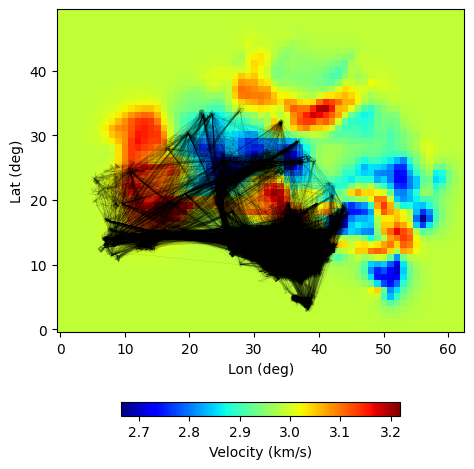

In [10]:

fig = plt.figure(figsize=(6, 6))
ax=plt.subplot(1,1,1)
plt.imshow(vel,cmap=plt.cm.jet, interpolation='none' ); 
ax.set_xlabel('Lon (deg)');
ax.set_ylabel('Lat (deg)');
plt.colorbar(orientation='horizontal',shrink=0.6,label='Velocity (km/s)');
plt.gca().invert_yaxis()
for ray_x, ray_y in ray_paths:
    ax.plot(ray_x, ray_y, 'k', linewidth=0.1,alpha=0.4)




In [7]:
# ###build ray path matrix 
# A=build_ray_matrix_sr(ray_paths, x0,y0,dx, dy, nx, ny,1)
# print(A.shape)



In [8]:
def tomoloopsr(vini,L2,niter,nx,ny,nd,obst,par_S,ifresid=False):
    L2=L2.toarray()

    slowness0=1./vini.flatten(order='F');
    d0=np.matmul(L2,slowness0) 	#L*s0=d0
    nm=L2.shape[1]  ####number of model parameters

    par_L={'matrix': L2, 'nm': nm, 'nd': nd}
    mm=np.zeros(nm);
	
    if ifresid:
        grad,err=conjgrad(None,matrix_lop,trianglen_lop, mm, None, obst-d0, 1, 0.000001, niter,0,[],par_L,par_S,0,ifres=1)
    else:
        grad=conjgrad(None,matrix_lop,trianglen_lop, mm, None, obst-d0, 1, 0.000001, niter,0,[],par_L,par_S,0)

    alpha=stepsize(obst,0.1,grad,slowness0,L2)
    # print(alpha)
    # alpha=0.01
    mm2=slowness0+alpha*grad
    
    v_est=1/mm2.reshape(ny, nx, order="C");
    if ifresid:
        return v_est,err
    else:
        return v_est

In [9]:
########Step 5 tomography inversion using DISC method
oniter=2  ####number of outer iteration
initer=5   ####number of inner iteration

v_low=2.5
v_hig=3.5

v_init=np.ones_like(vel)*3 #####initialize starting model

v_disc=v_init

nd=len(obst)

for i in range(oniter):
	_,ray_pathsini=compute_travel_times_sr(v_disc ,sources, receivers, dx, dy, nx, ny )     ###ray traceing based on the given model
	opsr=build_ray_matrix_sr(ray_pathsini, dx, dy, nx, ny,1)  ####build ray path matrix using the initial model

	nm=opsr.toarray().shape[1] 
	par_S={'nm':nm,'nd':nm,'nbox':[10,10,1],'ndat':[nx,ny,1],'ndim':3} ### shaping operator setting
	v_disc=tomoloopsr(v_disc,opsr,initer,nx,ny,nd,obst,par_S) ### gradient estimation and model update

	# v_disc = np.clip(v_disc, v_low, v_hig)
	
	print('iter=',i+1,msecal(obst,np.matmul(opsr.toarray(),1./v_disc.flatten(order='F'))))

IndexError: column index (-94) out of bounds

16.926839166920477 1181.1186306343288
16.926839166920477 1181.1186306343288


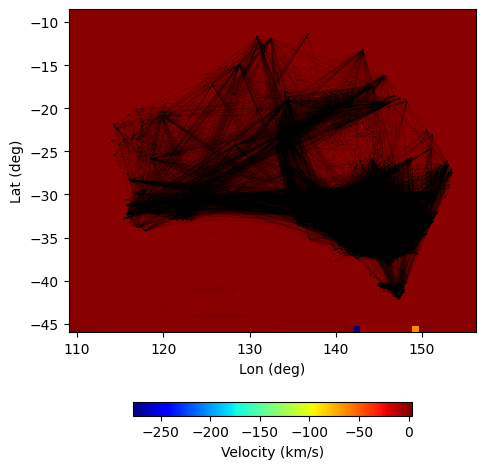

In [ ]:
print(traveltimes.min(),traveltimes.max())
print(obst.min(),obst.max())

fig = plt.figure(figsize=(6, 6))
ax=plt.subplot(1,1,1)
plt.imshow(v_disc.reshape(ny,nx),cmap=plt.cm.jet, interpolation='none', extent=[x0,xm,ym,y0]); 
ax.set_xlabel('Lon (deg)');
ax.set_ylabel('Lat (deg)');
plt.colorbar(orientation='horizontal',shrink=0.6,label='Velocity (km/s)');
plt.gca().invert_yaxis()
for ray_x, ray_y in ray_paths:
    ax.plot(ray_x, ray_y, 'k', linewidth=0.1,alpha=0.4)